In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("dataset_heart.csv")
print(df.head())

   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment  major vessels

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)


Shape: (270, 14)

Columns:
Index(['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='object')


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
print(df.info())

df.columns = df.columns.str.strip()
print("Columns after cleaning:")
print(df.columns)

df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:")
print(df.shape)

print("Heart disease values:")
print(df["heart disease"].value_counts())

print("Missing values after cleaning:")
print(df.isnull().sum())




Missing values:
age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64


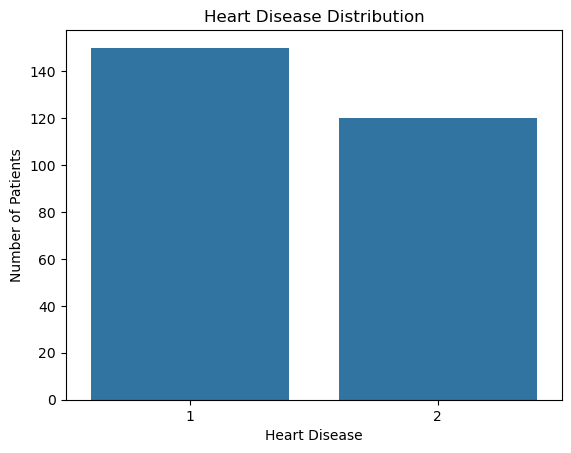

In [5]:
sns.countplot(data=df, x="heart disease")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

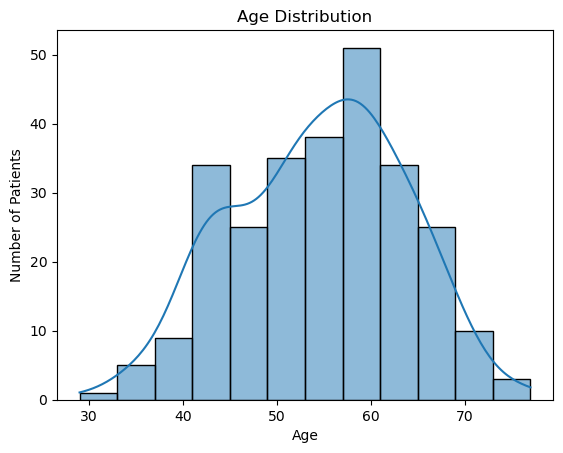

In [6]:
sns.histplot(data=df, x="age", kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


<Axes: xlabel='heart disease', ylabel='age'>

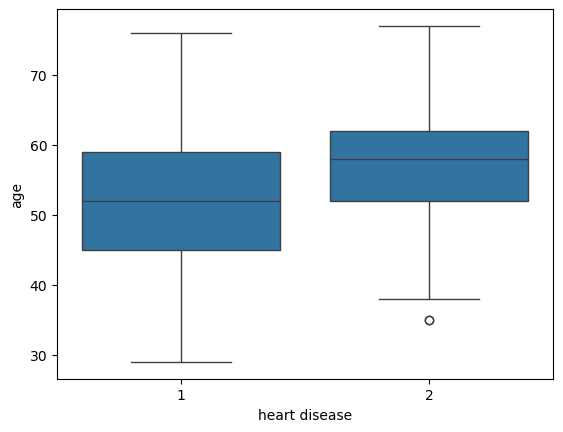

In [7]:
sns.boxplot(
    data=df,
    x="heart disease",
    y="age"
)

In [12]:
X = df.drop("heart disease", axis=1)
y = df["heart disease"]
print("Input features:")
print(X.columns)
print("\nTarget:")
print(y.name)

Input features:
Index(['age', 'sex', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal'],
      dtype='object')

Target:
heart disease


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (216, 13)
Testing data: (54, 13)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [19]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("K-Nearest Neighbors")

print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print("Precision:",
      precision_score(y_test, y_pred_knn))

print("Recall:",
      recall_score(y_test, y_pred_knn))

print("F1 Score:",
      f1_score(y_test, y_pred_knn))

K-Nearest Neighbors
Accuracy: 0.7962962962962963
Precision: 0.88
Recall: 0.7333333333333333
F1 Score: 0.8


In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("\nRandom Forest")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))


Random Forest
Accuracy: 0.8148148148148148
Precision: 0.8571428571428571
Recall: 0.8
F1 Score: 0.8275862068965517


In [20]:
svm = SVC()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("\nSupport Vector Machine")

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))



Support Vector Machine
Accuracy: 0.8148148148148148
Precision: 0.8571428571428571
Recall: 0.8
F1 Score: 0.8275862068965517


In [21]:
results = pd.DataFrame({
    "Model": [
        "K-Nearest Neighbors",
        "Random Forest",
        "Support Vector Machine"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],

    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

print(results)


                    Model  Accuracy  Precision    Recall  F1 Score
0     K-Nearest Neighbors  0.796296   0.880000  0.733333  0.800000
1           Random Forest  0.814815   0.857143  0.800000  0.827586
2  Support Vector Machine  0.814815   0.857143  0.800000  0.827586


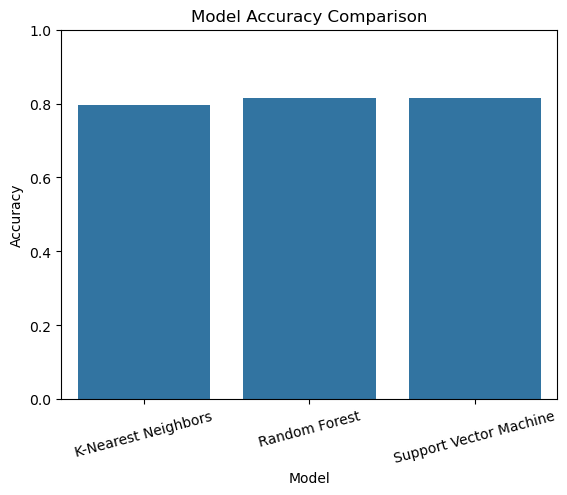

In [22]:
sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

cm = confusion_matrix(
    y_test,
    y_pred_knn
)


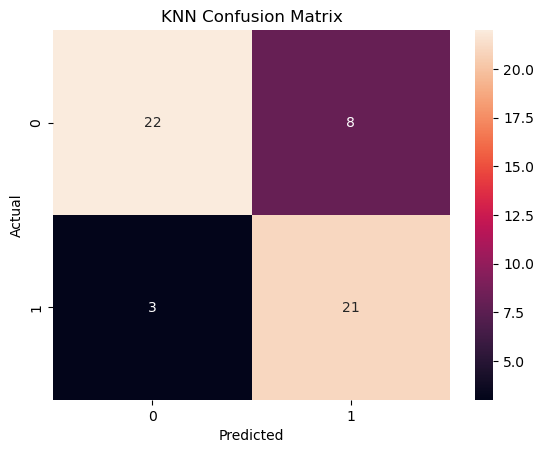

In [23]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm = confusion_matrix(
    y_test,
    y_pred_rf
)


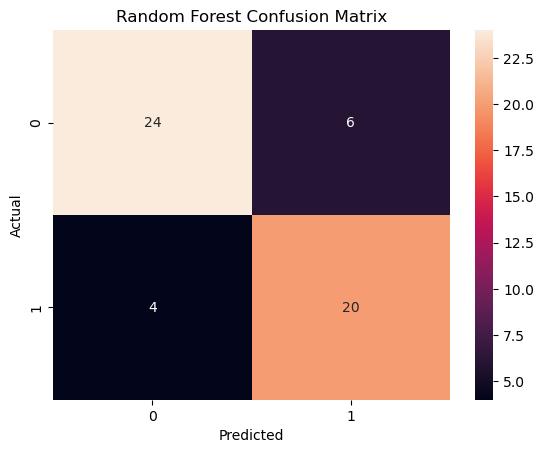

In [24]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

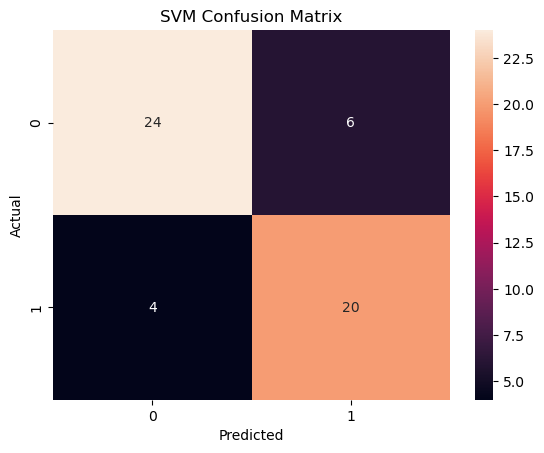

In [25]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [28]:
print("K-Nearest Neighbors")
print(classification_report(y_test, y_pred_knn))

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))

print("\nSupport Vector Machine")
print(classification_report(y_test, y_pred_svm))

K-Nearest Neighbors
              precision    recall  f1-score   support

           1       0.88      0.73      0.80        30
           2       0.72      0.88      0.79        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.81      0.80      0.80        54


Random Forest
              precision    recall  f1-score   support

           1       0.86      0.80      0.83        30
           2       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54


Support Vector Machine
              precision    recall  f1-score   support

           1       0.86      0.80      0.83        30
           2       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg   

In [27]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("\nBest Model:")
print(best_model)

print(
    "The models were used to predict whether a patient "
    "has heart disease."
)

print(
    "K-Nearest Neighbors, Random Forest and Support Vector "
    "Machine were compared using Accuracy, Precision, "
    "Recall and F1 Score."
)

print(
    "The model with the highest accuracy is:",
    best_model["Model"]
)


Best Model:
Model        Random Forest
Accuracy          0.814815
Precision         0.857143
Recall                 0.8
F1 Score          0.827586
Name: 1, dtype: object
The models were used to predict whether a patient has heart disease.
K-Nearest Neighbors, Random Forest and Support Vector Machine were compared using Accuracy, Precision, Recall and F1 Score.
The model with the highest accuracy is: Random Forest
